# Computing Distances on the Tropical Jacobian

Yueqi Cao, *Department of Mathematics, Imperial College London*

In [1]:
import sys
from pathlib import Path

src_path = Path("../src") 
sys.path.append(str(src_path))

import mgraph
from tropdist import *
import numpy as np
import networkx as nx
import scipy.optimize as sop
import matplotlib.pyplot as plt

# set random seed for reproducibility
np.random.seed(0)

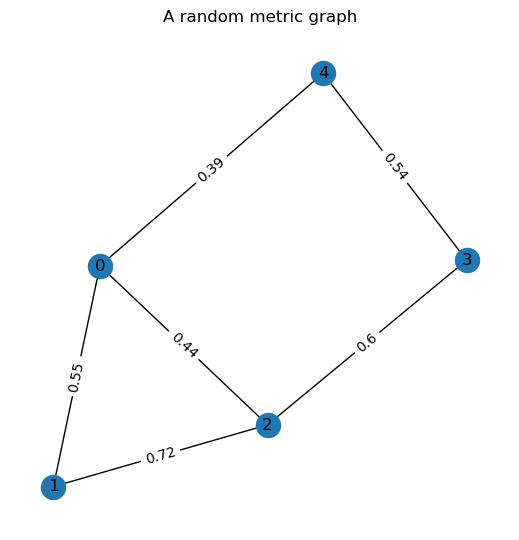

In [2]:
# Create a random metric graph
num_nodes = 5
g = 2 # set dimension=2 for illustration
MG = generate_random_graph(num_nodes, max_edges=num_nodes+g-1)

# draw the random graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG)
nx.draw(MG, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("A random metric graph")
plt.show()

## The Tropical Jacobian

the tropical polarization matrix is
 [[1.71 0.44]
 [0.44 1.97]]


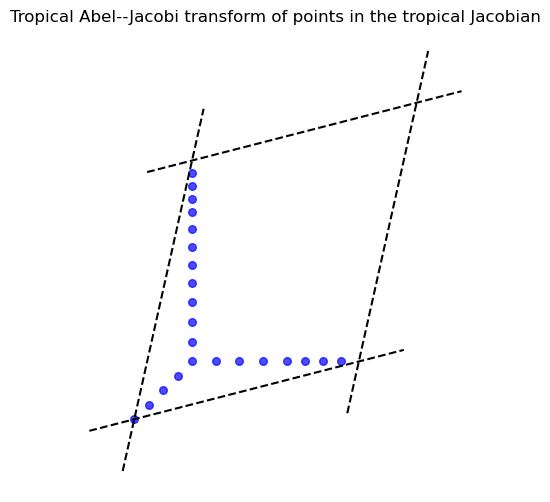

In [3]:
# compute the tropical Abel--Jacobi transform

# compute a minimal spanning tree
MST = nx.minimum_spanning_tree(MG)
# set the base point of the transform
base_point = list(MST.nodes())[0]
# compute the transform
V0 = MG.trop_transform(MST, base_point)
# sample more points from the transform
V = MG.interpolate(MST, V0, 3)
# compute the tropical polarization matrix
Q = MG.trop_polarization(MST)
print("the tropical polarization matrix is\n", Q)

# draw the tropical Abel--Jacobi transform
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q, ax)
# translate the vectors for better visualization
Vr = translate_to_fundamental_domain(V, Q)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Abel--Jacobi transform of points in the tropical Jacobian")
plt.show()

Is Q_LLL reduced?  True
The reduced lattice is 
 [[ 1.71 -1.27]
 [ 0.44  1.53]]


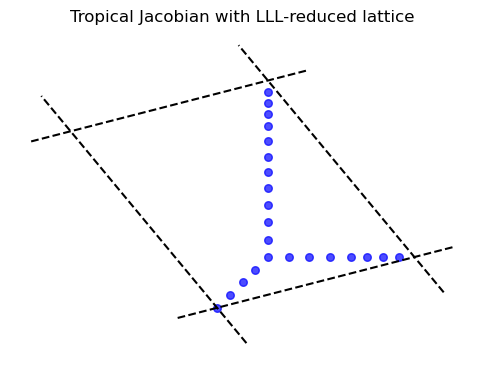

In [4]:
# compute the LLL-reduced lattice
Q_check, Q_LLL = LLL_reduced_lattice(Q)

# check if Q_LLL is indeed LLL-reduced
print("Is Q_LLL reduced? ", fp.LLL.is_reduced(Q_check))
print("The reduced lattice is \n", Q_LLL)

# draw the LLL-reduced lattice and points
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q_LLL, ax)
Vr = translate_to_fundamental_domain(V, Q_LLL)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Jacobian with LLL-reduced lattice")
plt.show()

## Computation of Tropical Polarization Distances

The lattice for L_2 metric is
 [[1.29741  0.163482]
 [0.163482 1.394013]]


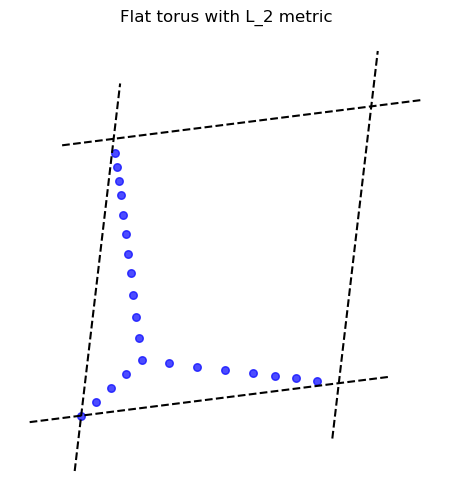

In [5]:
# transform the tropical Jacobian to a standard flat torus with the L_2 metric
V_L2, Q_sqrt = to_L2(V, Q)

# the lattice basis is given by Q_sqrt, apply the LLL-reduction to Q_sqrt
# due to the requirement of fpylll, Q_sqrt_check is scaled and transposed over Q_sqrt_LLL
Q_sqrt_check, Q_sqrt_LLL = LLL_reduced_lattice(Q_sqrt)
print("The lattice for L_2 metric is\n", Q_sqrt_LLL)

# draw the LLL-reduced lattice and points
fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q_sqrt_LLL, ax)
Vr = translate_to_fundamental_domain(V_L2, Q_sqrt_LLL)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Flat torus with L_2 metric")
plt.show()

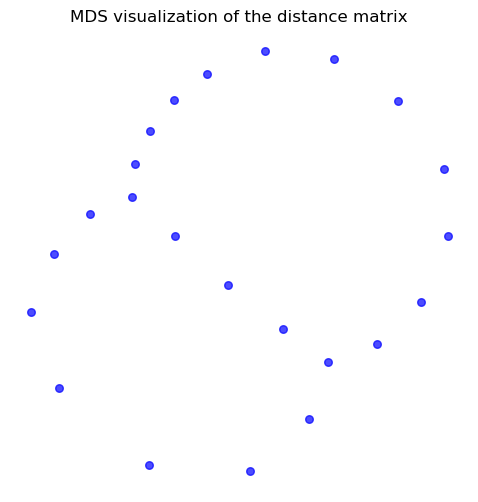

In [6]:
# compute the exact tropical polarization distance matrix

dist_exact = exact_L2_distance(V_L2, Q_sqrt)

# visualize the distance matrix using MDS
from sklearn.manifold import MDS
embedding = MDS(n_components=2, dissimilarity='precomputed')
X = embedding.fit_transform(dist_exact)
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(X[:,0], X[:,1], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("MDS visualization of the distance matrix")
plt.show()

## Fast Computation of Truncated Tropical Polarization Distances

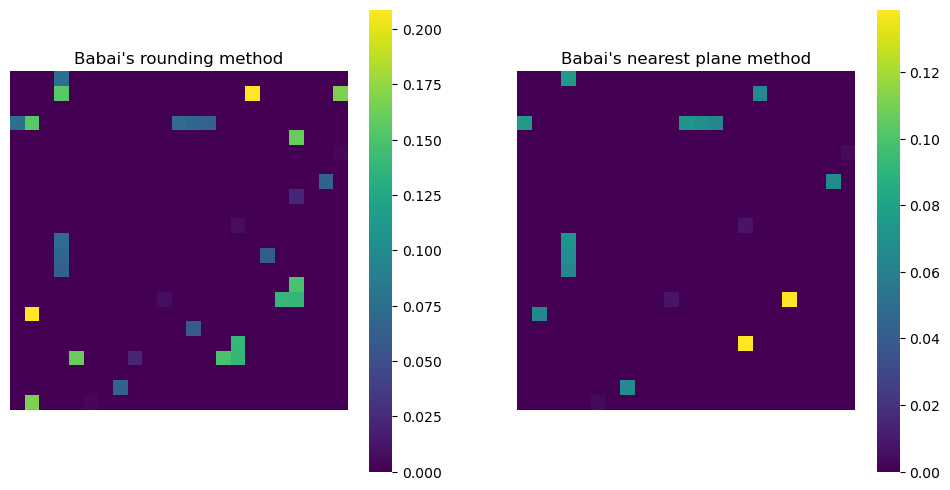

In [7]:
# Babai's algorithms to compute the closest point in the lattice

# Babai's rounding algorithm
dist_round = babai_rounding(V_L2, Q_sqrt_LLL)

# Babai's nearest plane algorithm
dist_nearest = babai_nearest_plane_original(V_L2, Q_sqrt_LLL)


# visualize the approximation errors
import seaborn as sns

error_round = np.abs(dist_exact - dist_round)
error_nearest = np.abs(dist_exact - dist_nearest)


fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.heatmap(error_round, ax=ax[0], cmap='viridis', fmt='.2f')
ax[0].set_aspect('equal')
ax[0].axis("off")
ax[0].set_title("Babai's rounding method")

sns.heatmap(error_nearest, ax=ax[1], cmap='viridis', fmt='.2f')
ax[1].set_aspect('equal')
ax[1].axis("off")
ax[1].set_title("Babai's nearest plane method")

plt.show()


In [15]:
# thresholding for the approximate distance matrix
threshold = 0.2
local_dist_mat = truncate_mat(dist_nearest, threshold)

error = np.abs(dist_exact - local_dist_mat)
error[np.isinf(error)] = 0
print("the approximation error for local distances is:", np.sqrt(np.sum(error**2)))

the approximation error for local distances is: 1.8169830447432734e-06


## Computation of Foster--Zhang Distances

In [ ]:
# computation using pyomo

In [9]:
#import pyomo.environ as pyo
# import scipy.optimize as sop

# Trop_dist = np.zeros((N,N))

# for i in range(N):
#     if i%10 == 1:
#         print(i)
#     for j in range(i+1,N):
#         b = E[:,i]-E[:,j]
#         model = pyo.ConcreteModel()
#         model.x = pyo.Var(range(homology_dim), domain=pyo.Integers)
#         model.y = pyo.Var(domain=pyo.NonNegativeReals)
#         model.OBJ = pyo.Objective(expr = model.y)
#         model.con = pyo.ConstraintList()
#         for k in range(homology_dim):
#             expr1 = -model.y
#             expr2 = -model.y
#             for r in range(homology_dim):
#                 expr1 += Q[k,r]*model.x[r]
#                 expr2 += -Q[k,r]*model.x[r]
#             model.con.add(expr1<=b[k])
#             model.con.add(expr2<=-b[k])
#         result = pyo.SolverFactory("gurobi").solve(model,tee=False)
#         Trop_dist[i,j] = model.y.value

# Trop_dist = Trop_dist+Trop_dist.T